# 4.2 案例实战 - 股票客户流失预警模型

In [2]:
# 读取数据
import pandas as pd
df = pd.read_excel(r"D:\1Ftostudy\商业数据分析\@Python大数据分析与机器学习商业案例实战\@Python大数据分析与机器学习商业案例实战\第4章 逻辑回归模型\源代码汇总_Jupyter Notebook格式（推荐）\股票客户流失.xlsx")
df.head()

,账户资金（元）,最后一次交易距今时间（天）,上月交易佣金（元）,累计交易佣金（元）,本券商使用时长（年）,是否流失
0,22686.5,297,149.25,2029.85,0,0
1,190055.0,42,284.75,3889.50,2,0
2,29733.5,233,269.25,2108.15,0,1
3,185667.5,44,211.50,3840.75,3,0
4,33648.5,213,353.50,2151.65,0,1


In [4]:
X = df.drop(columns='是否流失') 
y = df['是否流失']  

In [9]:
#划分训练集和测试集
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)  # 设置random_state使得每次划分的数据一样
# 可以删除 random_state=1，试试看每次的训练集和测试集各是什么

print(X_train.head()) # 显示训练集X_train的前5行，在别的代码编辑器里需要通过print()函数打印查看
print(y_train.head())  # 显示训练集y_train的前5行，在别的代码编辑器里需要通过print()函数打印查看
print(X_test.head())  # 显示测试集X_test的前5行，在别的代码编辑器里需要通过print()函数打印查看
print(y_test.head())  # 显示测试集y_test的前5行，在别的代码编辑器里需要通过print()函数打印查看

       账户资金（元）  最后一次交易距今时间（天）  上月交易佣金（元）  累计交易佣金（元）  本券商使用时长（年）
1814   43251.5            192      98.50    2258.35           0
5946  304449.5             22     369.50    5160.55           3
3881  441357.5              9     325.75    6681.75           5
2389  587076.5              2     427.25    8300.85           5
3676  204027.5             39     352.00    4044.75           2
1814    0
5946    1
3881    0
2389    0
3676    0
Name: 是否流失, dtype: int64
       账户资金（元）  最后一次交易距今时间（天）  上月交易佣金（元）  累计交易佣金（元）  本券商使用时长（年）
3381  318867.5             20     399.25    5320.75           3
6180  602466.5              2     512.00    8471.85           5
4829   67191.5            133     225.00    2524.35           0
3737   42495.5            188     253.00    2249.95           0
4249   79404.5            116     329.50    2660.05           0
3381    0
6180    0
4829    0
3737    1
4249    0
Name: 是否流失, dtype: int64


## 决策树模型

In [11]:
#模型搭建
# 决策树模型搭建
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
import matplotlib.pyplot as plt

# 创建决策树模型
dt_model = DecisionTreeClassifier(random_state=1, max_depth=3)
dt_model.fit(X_train, y_train)

# 模型预测
y_pred_dt = dt_model.predict(X_test)
print("决策树预测结果前100个：", y_pred_dt[0:100])

决策树预测结果前100个： [0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0
 0 0 0 0 0 1 1 1 0 0 1 0 1 0 0 0 0 1 0 0 1 0 0 0 0 1 1 0 0 0 1 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 1]


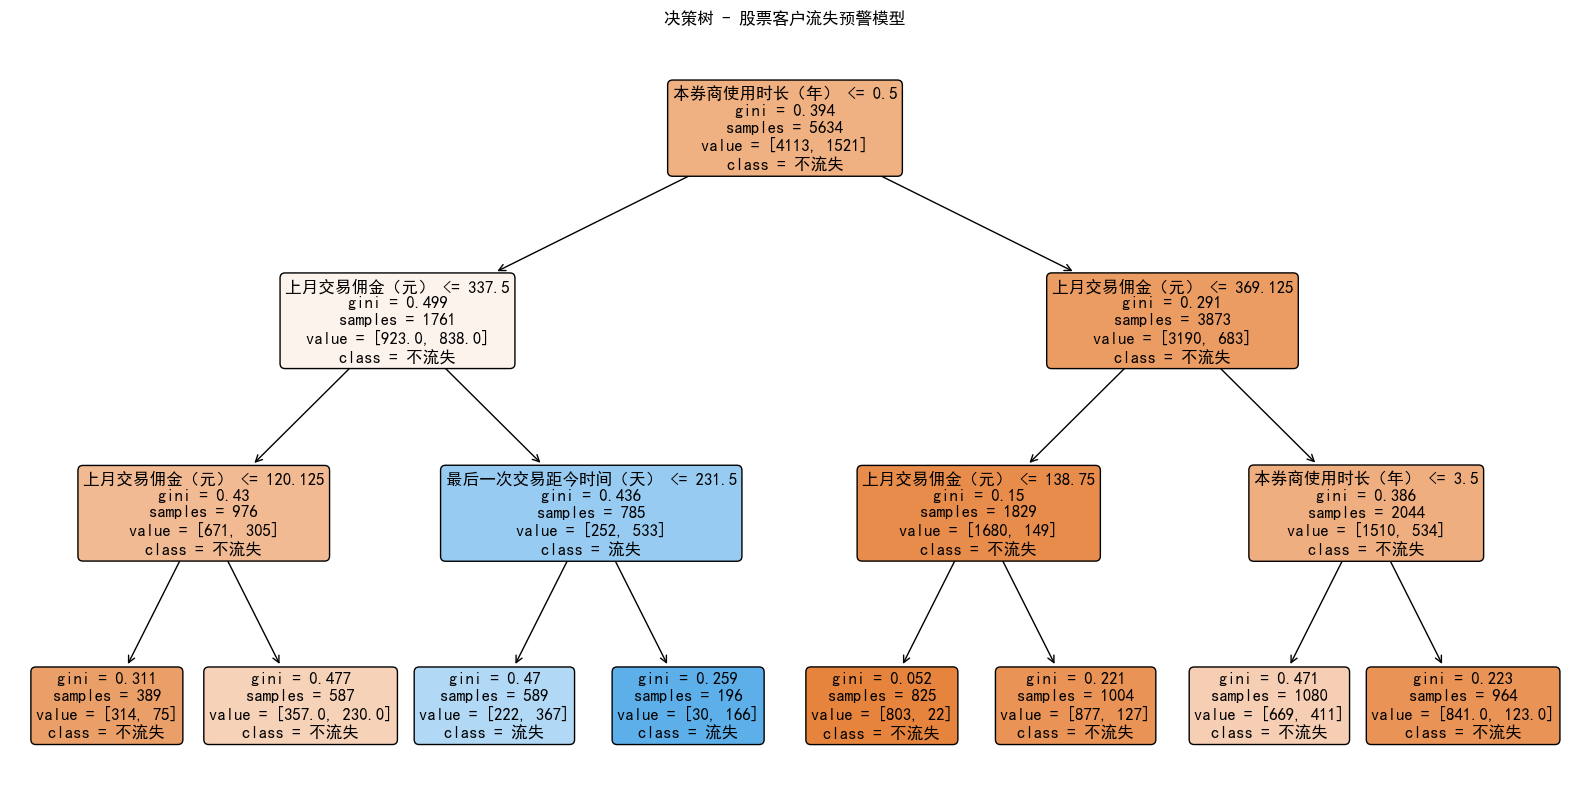

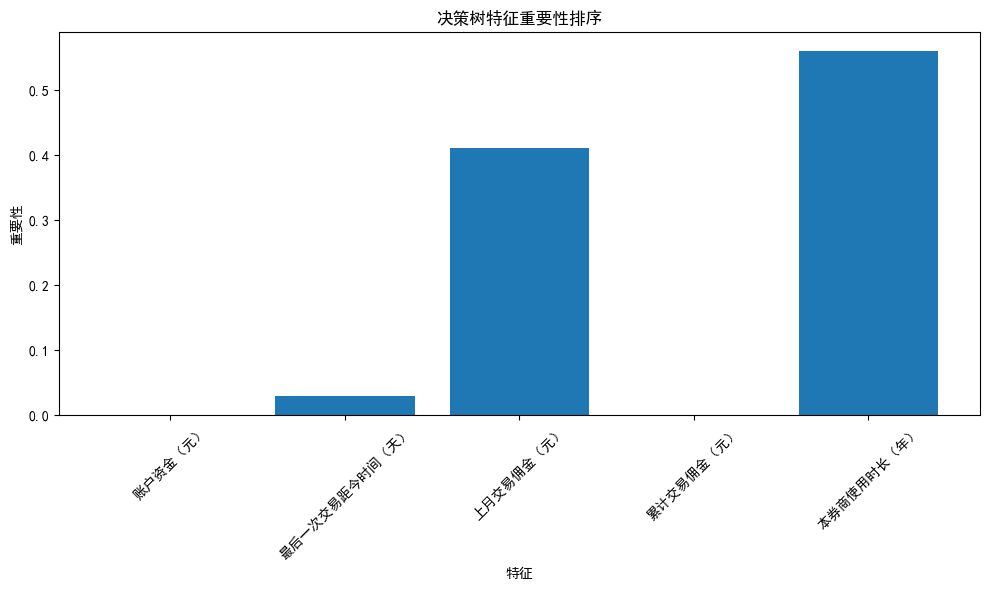

In [15]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# 设置 matplotlib 的默认字体（解决字体缺失警告）
plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体（支持中文显示）
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示为方块的问题

# 决策树可视化
plt.figure(figsize=(20, 10))
plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=['不流失', '流失'],
    filled=True,
    rounded=True,
    fontsize=12
)
plt.title('决策树 - 股票客户流失预警模型')
plt.show()

# 特征重要性可视化
feature_importance = dt_model.feature_importances_
features = X.columns

plt.figure(figsize=(10, 6))
plt.bar(features, feature_importance)
plt.xlabel('特征')
plt.ylabel('重要性')  # 修正：原代码缺少 y 轴标签
plt.title('决策树特征重要性排序')
plt.xticks(rotation=45)  # 可选：旋转 x 轴标签以提高可读性
plt.tight_layout()       # 可选：自动调整布局
plt.show()


In [17]:
#决策规则构造
# 查看决策规则
print("决策树深度:", dt_model.get_depth())
print("叶子节点数量:", dt_model.get_n_leaves())

# 获取决策路径（示例：第一条测试数据）
decision_path = dt_model.decision_path(X_test.iloc[0:1])
print("决策路径:", decision_path)

# 特征重要性排序
feature_importance_df = pd.DataFrame({
    '特征': features,
    '重要性': feature_importance
}).sort_values('重要性', ascending=False)
print("特征重要性排序:")
print(feature_importance_df)

决策树深度: 3
叶子节点数量: 8
决策路径:   (0, 0)	1
  (0, 8)	1
  (0, 12)	1
  (0, 13)	1
特征重要性排序:
              特征       重要性
4     本券商使用时长（年）  0.560344
2      上月交易佣金（元）  0.410411
1  最后一次交易距今时间（天）  0.029245
0        账户资金（元）  0.000000
3      累计交易佣金（元）  0.000000


## 随机森林模型

In [24]:
#模型搭建
# 随机森林模型搭建
from sklearn.ensemble import RandomForestClassifier

# 创建随机森林模型
rf_model = RandomForestClassifier(n_estimators=100, random_state=1, max_depth=5)
rf_model.fit(X_train, y_train)

# 模型预测
y_pred_rf = rf_model.predict(X_test)
print("随机森林预测结果前100个：", y_pred_rf[0:100])

# 预测概率
y_pred_proba_rf = rf_model.predict_proba(X_test)
print("随机森林预测概率前5个：")
print(y_pred_proba_rf[0:5])

随机森林预测结果前100个： [0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0
 1 0 0 0 0 1 1 1 0 0 1 0 1 0 0 0 0 1 0 0 0 0 0 0 0 1 1 0 1 0 1 0 0 1 0 0 0
 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 1 0 0 0 1]
随机森林预测概率前5个：
[[0.73936963 0.26063037]
 [0.80496163 0.19503837]
 [0.77744648 0.22255352]
 [0.68710187 0.31289813]
 [0.73972136 0.26027864]]


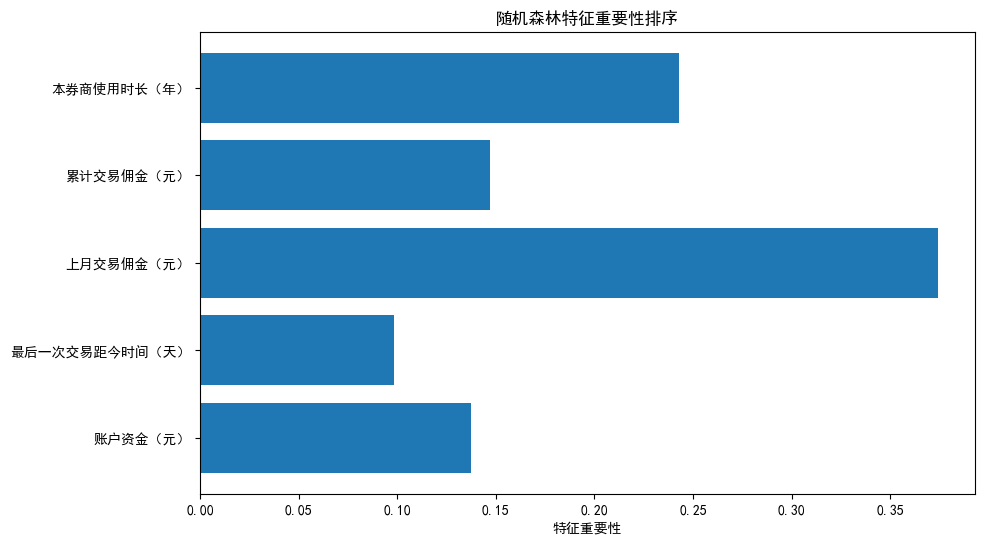

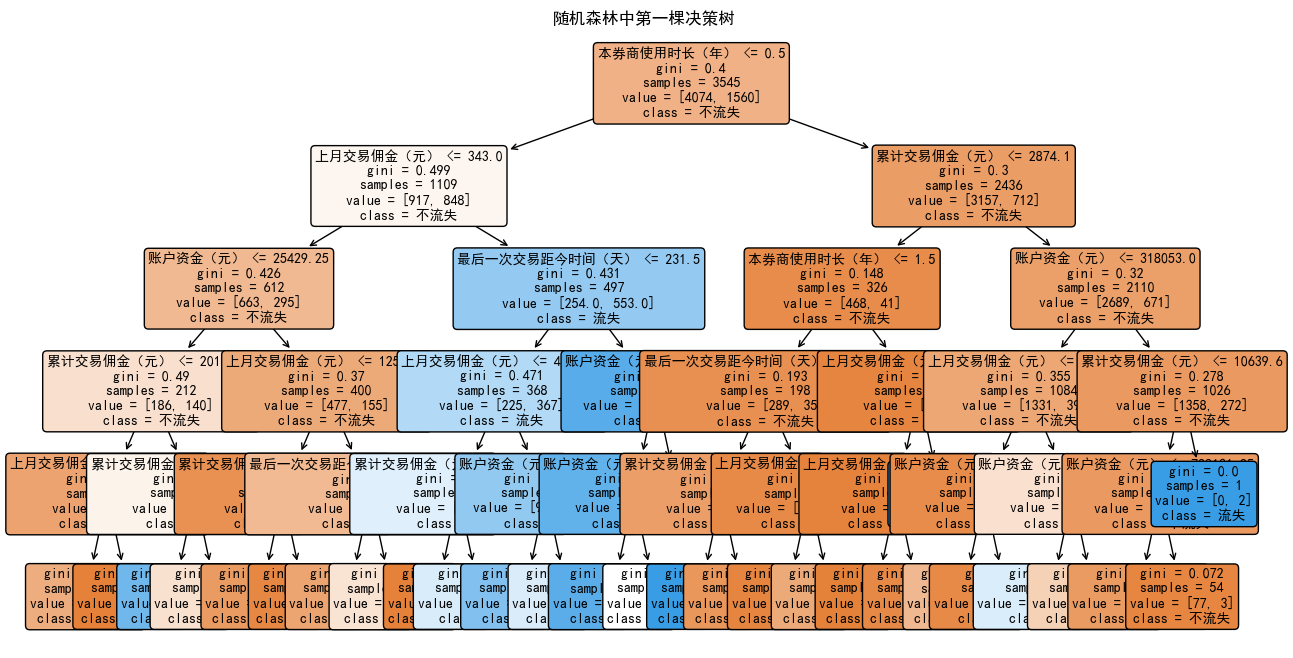

In [26]:
#模型可视化
# 随机森林特征重要性可视化
rf_feature_importance = rf_model.feature_importances_

plt.figure(figsize=(10, 6))
plt.barh(features, rf_feature_importance)
plt.xlabel('特征重要性')
plt.title('随机森林特征重要性排序')
plt.show()

# 单棵决策树可视化（随机森林中的第一棵树）
plt.figure(figsize=(15, 8))
tree.plot_tree(rf_model.estimators_[0], 
               feature_names=X.columns,
               class_names=['不流失', '流失'],
               filled=True,
               rounded=True,
               fontsize=10)
plt.title('随机森林中第一棵决策树')
plt.show()

In [34]:
# 集成学习方程构造
# 随机森林模型内部结构分析
print(f"随机森林中树的数量：{len(rf_model.estimators_)}")

# 获取每棵树的深度
tree_depths = [tree.get_depth() for tree in rf_model.estimators_]
print(f"每棵树的深度：{tree_depths[:5]}")  # 只显示前5棵树的深度

# 特征重要性分析
rf_feature_importance_df = pd.DataFrame({
    '特征': features,
    '重要性': rf_feature_importance
}).sort_values('重要性', ascending=False)

print("\n随机森林特征重要性排序:")
print(rf_feature_importance_df)

# 查看多棵树的投票结果（示例）- 修正版本
print("\n前5个样本在随机森林中的投票情况:")
for i in range(5):
    sample_data = X_test.iloc[i].values.reshape(1, -1)
    sample_predictions = [
        tree.predict(sample_data)[0] 
        for tree in rf_model.estimators_
    ]
    print(f"样本{i}: 流失票数={sum(sample_predictions)}, 不流失票数={len(sample_predictions)-sum(sample_predictions)}")

随机森林中树的数量：100
每棵树的深度：[5, 5, 5, 5, 5]

随机森林特征重要性排序:
              特征       重要性
2      上月交易佣金（元）  0.374335
4     本券商使用时长（年）  0.242688
3      累计交易佣金（元）  0.147012
0        账户资金（元）  0.137502
1  最后一次交易距今时间（天）  0.098464

前5个样本在随机森林中的投票情况:
样本0: 流失票数=2.0, 不流失票数=98.0
样本1: 流失票数=1.0, 不流失票数=99.0
样本2: 流失票数=0.0, 不流失票数=100.0
样本3: 流失票数=13.0, 不流失票数=87.0
样本4: 流失票数=6.0, 不流失票数=94.0


## 支持向量机模型


In [37]:
#模型搭建
# 支持向量机模型搭建
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# 数据标准化（SVM对特征尺度敏感）
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 创建SVM模型
svm_model = SVC(kernel='linear', probability=True, random_state=1)
svm_model.fit(X_train_scaled, y_train)

# 模型预测
y_pred_svm = svm_model.predict(X_test_scaled)
print("SVM预测结果前100个：", y_pred_svm[0:100])

# 预测概率
y_pred_proba_svm = svm_model.predict_proba(X_test_scaled)
print("SVM预测概率前5个：")
print(y_pred_proba_svm[0:5])

SVM预测结果前100个： [0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 1 1 0 0 0 1 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 1 0 0 0 0]
SVM预测概率前5个：
[[0.79108047 0.20891953]
 [0.78600474 0.21399526]
 [0.88005504 0.11994496]
 [0.67862764 0.32137236]
 [0.73233544 0.26766456]]


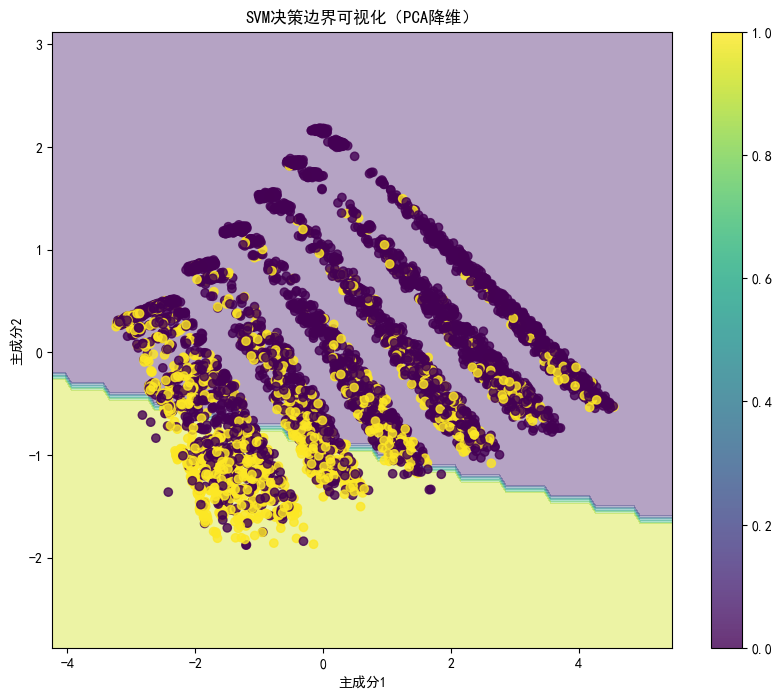

In [41]:
# 模型可视化
# SVM决策边界可视化（使用前两个主要特征）
from sklearn.decomposition import PCA
import numpy as np  # 添加这行导入
import matplotlib.pyplot as plt

# 使用PCA降维到2维进行可视化
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)

# 在降维后的数据上训练SVM
svm_2d = SVC(kernel='linear', probability=True, random_state=1)
svm_2d.fit(X_pca, y_train)

# 创建网格点
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

# 预测每个网格点
Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 绘制决策边界
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.4)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, alpha=0.8)
plt.xlabel('主成分1')
plt.ylabel('主成分2')
plt.title('SVM决策边界可视化（PCA降维）')
plt.colorbar()
plt.show()

In [43]:
#支持向量机方程构造
# SVM线性方程参数
print("SVM系数 (权重):", svm_model.coef_)
print("SVM截距:", svm_model.intercept_)

# 支持向量信息
print("支持向量数量:", len(svm_model.support_))
print("支持向量索引:", svm_model.support_[:10])  # 显示前10个支持向量的索引

# 通过SVM方程计算决策函数值
decision_function = svm_model.decision_function(X_test_scaled)
print("前5个测试样本的决策函数值:", decision_function[:5])

# SVM分类方程：w·x + b = 0
print("SVM分类方程:")
equation = " + ".join([f"({coef:.6f})*{feature}" for coef, feature in zip(svm_model.coef_[0], X.columns)])
print(f"决策函数: f(x) = {equation} + ({svm_model.intercept_[0]:.6f})")
print("分类规则: f(x) >= 0 → 不流失, f(x) < 0 → 流失")

# 计算前5个样本通过方程得到的值
for i in range(5):
    linear_output = np.dot(X_test_scaled[i], svm_model.coef_[0]) + svm_model.intercept_[0]
    print(f"样本{i}: 线性输出值 = {linear_output:.6f}, 预测类别 = {y_pred_svm[i]}")

SVM系数 (权重): [[-0.60636735  0.74287337  1.21587452 -0.60636735  0.86858632]]
SVM截距: [-0.83045446]
支持向量数量: 2720
支持向量索引: [ 4  7  8 11 12 20 23 32 49 52]
前5个测试样本的决策函数值: [-0.93139195 -0.91170597 -1.35916965 -0.55374563 -0.72125578]
SVM分类方程:
决策函数: f(x) = (-0.606367)*账户资金（元） + (0.742873)*最后一次交易距今时间（天） + (1.215875)*上月交易佣金（元） + (-0.606367)*累计交易佣金（元） + (0.868586)*本券商使用时长（年） + (-0.830454)
分类规则: f(x) >= 0 → 不流失, f(x) < 0 → 流失
样本0: 线性输出值 = -0.931392, 预测类别 = 0
样本1: 线性输出值 = -0.911706, 预测类别 = 0
样本2: 线性输出值 = -1.359170, 预测类别 = 0
样本3: 线性输出值 = -0.553746, 预测类别 = 0
样本4: 线性输出值 = -0.721256, 预测类别 = 0


In [45]:
# 三种模型的评估对比
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

models = {
    '决策树': (y_pred_dt, dt_model),
    '随机森林': (y_pred_rf, rf_model),
    '支持向量机': (y_pred_svm, svm_model)
}

print("模型性能对比:")
print("="*50)
for name, (y_pred, model) in models.items():
    accuracy = accuracy_score(y_test, y_pred)
    print(f"{name} 准确率: {accuracy:.4f}")
    
# 详细评估决策树模型
print("\n决策树模型详细评估:")
print(classification_report(y_test, y_pred_dt, target_names=['不流失', '流失']))

模型性能对比:
决策树 准确率: 0.7956
随机森林 准确率: 0.8062
支持向量机 准确率: 0.7942

决策树模型详细评估:
              precision    recall  f1-score   support

         不流失       0.82      0.94      0.87      1061
          流失       0.65      0.36      0.47       348

    accuracy                           0.80      1409
   macro avg       0.74      0.65      0.67      1409
weighted avg       0.78      0.80      0.77      1409

